# Sherweb Support Center — Forecasting Pipeline
Run each cell in order. Each step is self-contained.

## STEP 1 — Load and Explore the Data

In [11]:
import pandas as pd

df = pd.read_csv('data.csv', encoding='utf-8-sig')

print('=== COLUMN NAMES ===')
print(df.columns.tolist())

print('\n=== FIRST 5 ROWS ===')
display(df.head())

df['DT_Initiate_EST_QH'] = pd.to_datetime(df['DT_Initiate_EST_QH'])

print('\n=== DATE RANGE ===')
print(f'  Min date : {df["DT_Initiate_EST_QH"].min()}')
print(f'  Max date : {df["DT_Initiate_EST_QH"].max()}')

print(f'\n=== TOTAL INTERACTIONS ===')
print(f'  {len(df):,} rows')

print('\n=== MISSING VALUES PER COLUMN ===')
print(df.isnull().sum().to_string())

=== COLUMN NAMES ===
['DT_Initiate_EST_QH', 'ID_Activity', 'ID_Incident', 'ID', 'Name', 'Area', 'Queue', 'IVR Language', 'Channel', 'AbandonType', 'isOffer', 'T_Talk', 'T_Hold', 'T_Queue', 'T_Wrapup']

=== FIRST 5 ROWS ===


,DT_Initiate_EST_QH,ID_Activity,ID_Incident,ID,Name,Area,Queue,IVR Language,Channel,AbandonType,isOffer,T_Talk,T_Hold,T_Queue,T_Wrapup
0,2025-07-04 07:45,6e98adbd-96f9-4af5-8e92-818d49c2397d,NaN,4352,Rita Benjelloun Touimi,TSS O365 Hex,Support Chat,English,Live chat,NaN,1,204.0,NaN,12,995.0
1,2025-07-04 08:00,0fc32772-43dd-4df9-a91e-67b6f6282719,9cb38a72-c258-f011-bec2-002248aefb36,1490,Zachary Morin,TSS O365 Hex,Support Chat,English,Live chat,NaN,1,158.0,NaN,106,354.0
2,2025-07-04 10:00,125b0ae2-2133-43cc-a2ba-a5cea01b8fc7,6d3df2e9-4361-ed11-8166-001dd8b799a2,2077,Elphie Nikita Abe Lema,TSS O365 Hex,Support Chat,English,Live chat,NaN,1,479.0,NaN,116,983.0
3,2025-07-04 10:15,d27c3978-0b61-4f15-a1e7-29f136b14327,39e1548f-7740-ef11-a317-6045bd5d1869,1490,Zachary Morin,TSS O365 Hex,Support Chat,English,Live chat,NaN,1,1920.0,NaN,136,1174.0
4,2025-07-04 10:15,f5f344a1-b44e-47c7-ab7d-2b338c09dfb5,NaN,2077,Elphie Nikita Abe Lema,TSS O365 Hex,Support Chat,English,Live chat,NaN,1,92.0,NaN,1762,1111.0



=== DATE RANGE ===
  Min date : 2025-07-04 07:45:00
  Max date : 2026-05-04 06:15:00

=== TOTAL INTERACTIONS ===
  25,365 rows

=== MISSING VALUES PER COLUMN ===
DT_Initiate_EST_QH        0
ID_Activity               0
ID_Incident           10564
ID                        0
Name                      0
Area                      0
Queue                     0
IVR Language              0
Channel                   0
AbandonType           25340
isOffer                   0
T_Talk                  213
T_Hold                21777
T_Queue                   0
T_Wrapup                909


## STEP 2 — Clean the Data

### 2a — Justification : vérification visuelle de la période Noël / Nouvel An

Avant de supprimer des données, on vérifie visuellement que la période Noël/NY
a bien un comportement anormal par rapport au reste de l'année.

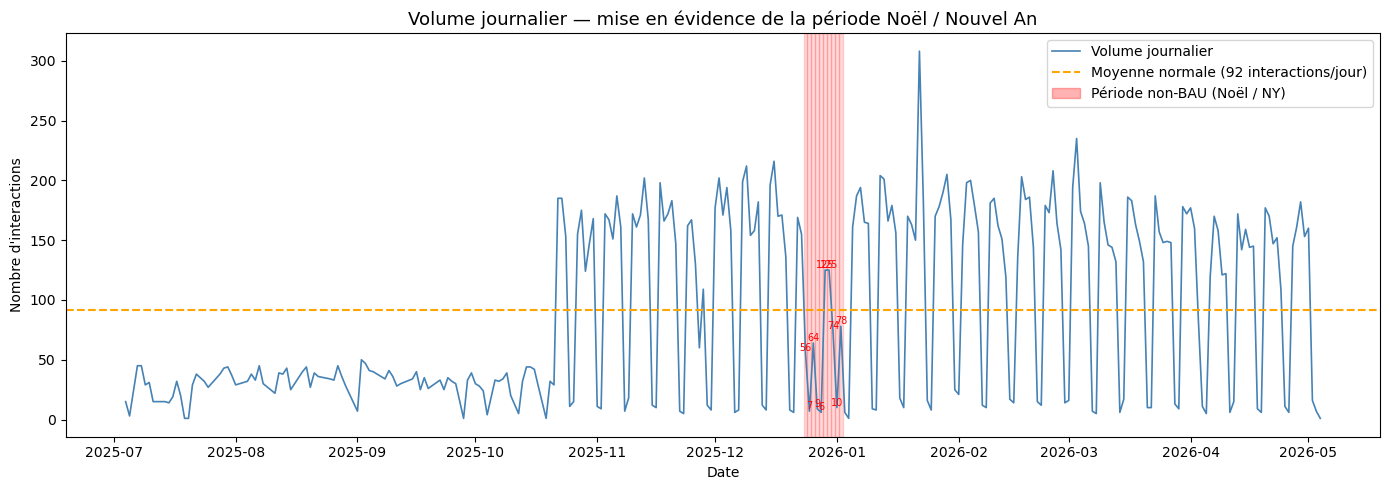

--- Volume moyen par période ---
  Hors fêtes (BAU)  : 92 interactions/jour
  Période Noël/NY   : 55 interactions/jour
  Réduction         : 40%

--- Détail jour par jour (période fêtes) ---
      date  volume
2025-12-24      56
2025-12-25       7
2025-12-26      64
2025-12-27       9
2025-12-28       6
2025-12-29     125
2025-12-30     125
2025-12-31      74
2026-01-01      10
2026-01-02      78


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv('data.csv', encoding='utf-8-sig')
df['DT_Initiate_EST_QH'] = pd.to_datetime(df['DT_Initiate_EST_QH'])

# Volume journalier
daily = df.groupby(df['DT_Initiate_EST_QH'].dt.date).size().reset_index()
daily.columns = ['date', 'volume']
daily['date'] = pd.to_datetime(daily['date'])

def is_non_bau(dt):
    if dt.month == 12 and dt.day >= 24:
        return True
    if dt.month == 1 and dt.day <= 2:
        return True
    return False

daily['is_non_bau'] = daily['date'].apply(is_non_bau)
mean_normal = daily[~daily['is_non_bau']]['volume'].mean()

fig, ax = plt.subplots(figsize=(14, 5))

for _, row in daily[daily['is_non_bau']].iterrows():
    ax.axvspan(row['date'] - pd.Timedelta(hours=12),
               row['date'] + pd.Timedelta(hours=12),
               color='red', alpha=0.15)

ax.plot(daily['date'], daily['volume'], color='steelblue', linewidth=1.2, label='Volume journalier')
ax.axhline(mean_normal, color='orange', linestyle='--', linewidth=1.5,
           label=f'Moyenne normale ({mean_normal:.0f} interactions/jour)')

for _, row in daily[daily['is_non_bau']].iterrows():
    ax.annotate(f"{int(row['volume'])}", xy=(row['date'], row['volume']),
                fontsize=7, color='red', ha='center', va='bottom')

ax.set_title('Volume journalier — mise en évidence de la période Noël / Nouvel An', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel("Nombre d'interactions")
red_patch = mpatches.Patch(color='red', alpha=0.3, label='Période non-BAU (Noël / NY)')
ax.legend(handles=[ax.lines[0], ax.lines[1], red_patch])
plt.tight_layout()
plt.show()

print('--- Volume moyen par période ---')
print(f'  Hors fêtes (BAU)  : {mean_normal:.0f} interactions/jour')
print(f'  Période Noël/NY   : {daily[daily["is_non_bau"]]["volume"].mean():.0f} interactions/jour')
print(f'  Réduction         : {(1 - daily[daily["is_non_bau"]]["volume"].mean() / mean_normal)*100:.0f}%')
print('\n--- Détail jour par jour (période fêtes) ---')
print(daily[daily['is_non_bau']][['date', 'volume']].to_string(index=False))

### 2b — Validation du seuil de détection

Le seuil de 40% du maximum est un choix empirique. On vérifie ici qu'il est robuste
en testant plusieurs valeurs (25% → 55%) et en s'assurant qu'elles donnent toutes
la même date de coupure.

In [13]:
import pandas as pd

df = pd.read_csv('data.csv', encoding='utf-8-sig')
df['DT_Initiate_EST_QH'] = pd.to_datetime(df['DT_Initiate_EST_QH'])

daily = df.groupby(df['DT_Initiate_EST_QH'].dt.date).size().reset_index()
daily.columns = ['date', 'volume']
daily['date'] = pd.to_datetime(daily['date'])
daily['rolling_7'] = daily['volume'].rolling(7, center=True).mean()

print(f"{'Seuil (% du max)':<20} | Date de coupure détectée")
print("-" * 45)

cutoffs = []
for pct in range(25, 60, 5):
    threshold = daily['rolling_7'].max() * (pct / 100)
    daily['above'] = daily['rolling_7'] > threshold
    daily['stable_above'] = daily['above'].rolling(7).sum() >= 5
    candidates = daily[daily['stable_above']]['date']
    if len(candidates) == 0:
        print(f"  {pct}%{'':<16} | Aucune date trouvée")
        continue
    first_stable = candidates.min()
    cutoff = first_stable - pd.Timedelta(days=first_stable.dayofweek)
    cutoffs.append(cutoff)
    print(f"  {pct}%{'':<16} | {cutoff.date()}")

if len(set(cutoffs)) == 1:
    print(f"\n✓ Date stable pour tous les seuils testés → coupure confirmée au {cutoffs[0].date()}")
else:
    print(f"\n⚠ La date varie selon le seuil — vérification manuelle recommandée")

Seuil (% du max)     | Date de coupure détectée
---------------------------------------------
  25%                 | 2025-10-20
  30%                 | 2025-10-20
  35%                 | 2025-10-20
  40%                 | 2025-10-20
  45%                 | 2025-10-20
  50%                 | 2025-10-20
  55%                 | 2025-10-20

✓ Date stable pour tous les seuils testés → coupure confirmée au 2025-10-20


### 2c — Nettoyage : suppression des lignes vides, de la période test et de la période non-BAU

Deux exclusions justifiées par les analyses ci-dessus :
- **Période test** (avant le 20 oct 2025) : volume ~3x plus faible, non représentatif de la production
- **Période Noël/NY** (24 déc → 2 jan) : volume −40%, comportement anormal hors BAU

In [14]:
import pandas as pd

df = pd.read_csv('data.csv', encoding='utf-8-sig')
original_count = len(df)
print(f'Starting rows: {original_count:,}')

df['DT_Initiate_EST_QH'] = pd.to_datetime(df['DT_Initiate_EST_QH'])

# --- 1. Supprimer les lignes vides ---
before = len(df)
df = df.dropna(subset=['DT_Initiate_EST_QH', 'ID_Activity'])
removed_empty = before - len(df)
print(f'Rows removed (missing timestamp or activity ID): {removed_empty}')

# --- 2. Détecter automatiquement la fin de la période test ---
daily = df.groupby(df['DT_Initiate_EST_QH'].dt.date).size().reset_index()
daily.columns = ['date', 'volume']
daily['date'] = pd.to_datetime(daily['date'])
daily['rolling_7'] = daily['volume'].rolling(7, center=True).mean()
threshold = daily['rolling_7'].max() * 0.40
daily['above'] = daily['rolling_7'] > threshold
daily['stable_above'] = daily['above'].rolling(7).sum() >= 5
first_stable = daily[daily['stable_above']]['date'].min()
TEST_CUTOFF = first_stable - pd.Timedelta(days=first_stable.dayofweek)

before = len(df)
df = df[df['DT_Initiate_EST_QH'] >= TEST_CUTOFF]
removed_test = before - len(df)
print(f'Rows removed (test period before {TEST_CUTOFF.date()}): {removed_test:,}')

# --- 3. Supprimer la période Noël / Nouvel An ---
def is_non_bau(dt):
    if dt.month == 12 and dt.day >= 24:
        return True
    if dt.month == 1 and dt.day <= 2:
        return True
    return False

df['is_non_BAU'] = df['DT_Initiate_EST_QH'].apply(is_non_bau)
non_bau_count = df['is_non_BAU'].sum()
print(f'Rows flagged as non-BAU (Xmas/NY period): {non_bau_count:,}')

df_non_bau = df[df['is_non_BAU']].copy()
df_clean   = df[~df['is_non_BAU']].copy()

print(f'\n--- Summary ---')
print(f'  Original rows        : {original_count:,}')
print(f'  Removed (empty)      : {removed_empty:,}')
print(f'  Removed (test)       : {removed_test:,}')
print(f'  Removed (non-BAU)    : {non_bau_count:,}')
print(f'  Remaining clean rows : {len(df_clean):,}')
print(f'\nClean date range: {df_clean["DT_Initiate_EST_QH"].min()} → {df_clean["DT_Initiate_EST_QH"].max()}')

df_clean.to_csv('/tmp/sherweb_clean.csv', index=False)
print('\nClean dataset saved to /tmp/sherweb_clean.csv')

Starting rows: 25,365
Rows removed (missing timestamp or activity ID): 0
Rows removed (test period before 2025-10-20): 2,526
Rows flagged as non-BAU (Xmas/NY period): 554

--- Summary ---
  Original rows        : 25,365
  Removed (empty)      : 0
  Removed (test)       : 2,526
  Removed (non-BAU)    : 554
  Remaining clean rows : 22,285

Clean date range: 2025-10-20 00:45:00 → 2026-05-04 06:15:00

Clean dataset saved to /tmp/sherweb_clean.csv


## STEP 3 — Volume per 15-Minute Interval

In [15]:
# Step 3 code will be added here

## STEP 4 — Naive Forecast (Baseline)

In [16]:
# Step 4 code will be added here

## STEP 5 — EWM (Exponential Weighted Moving Average)

In [17]:
# Step 5 code will be added here

## STEP 6 — OLS Trend (Long-Term Growth)

In [18]:
# Step 6 code will be added here

## STEP 7 — Z-Score Anomaly Detection

In [19]:
# Step 7 code will be added here

## STEP 8 — 56-Day Forecast

In [20]:
# Step 8 code will be added here

## STEP 9 — Summary for Management

In [21]:
# Step 9 code will be added here